In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
file_path = 'datasetFolder/processed_dataset2.csv'  # Replace with the path to your dataset
data = pd.read_csv(file_path, encoding='latin-1')

# Rename columns for clarity (if not already clear)
data.columns = ['target', 'id', 'date', 'flag', 'user', 'text']

# Split into features and target
X = data['text']  # The stemmed text
y = data['target']  # Target labels (0 = negative, 1 = positive)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize the text using TfidfVectorizer
vectorizer = TfidfVectorizer(ngram_range=(1, 2))  # Unigrams + Bigrams
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=30, random_state=42)
rf_model.fit(X_train_vec, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_vec)

# # Evaluate the model
# accuracy = accuracy_score(y_test, y_pred)
# print("Random Forest Accuracy:", accuracy)
# print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [19]:

import numpy as np
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error
from termcolor import colored



# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(colored(f"Random Forest Accuracy: {accuracy:.4f}", 'green'))

# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(colored(f"\nMean Absolute Error (MAE): {mae:.4f}", 'red'))
print(colored(f"Mean Squared Error (MSE): {mse:.4f}", 'magenta'))
print(colored(f"Root Mean Squared Error (RMSE): {rmse:.4f}", 'magenta'))

# Classification Report
report = classification_report(y_test, y_pred, output_dict=True)
# 
print(colored("\nClassification Report:", 'blue'))
print(colored(classification_report(y_test, y_pred), 'white'))

# Extract Precision, Recall, and F1-Score for both classes (Negative = 0, Positive = 1)
precision_neg = report['0']['precision']
recall_neg = report['0']['recall']
f1_neg = report['0']['f1-score']

precision_pos = report['1']['precision']
recall_pos = report['1']['recall']
f1_pos = report['1']['f1-score']

# print(colored("\nPrecision, Recall, and F1-Score for Negative (0) class:", 'cyan'))
# print(colored("Precision for Positive: "))
print(colored(f"Precision: {precision_neg:.4f}", 'cyan'))
print(colored(f"Recall: {recall_neg:.4f}", 'cyan'))
print(colored(f"F1-Score: {f1_neg:.4f}", 'cyan'))

# print(colored("\nPrecision, Recall, and F1-Score for Positive (1) class:", 'yellow'))
# print(colored("Precision for negative: "))
print(colored(f"Precision: {precision_pos:.4f}", 'yellow'))
print(colored(f"Recall: {recall_pos:.4f}", 'yellow'))
print(colored(f"F1-Score: {f1_pos:.4f}", 'yellow'))

Random Forest Accuracy: 0.7178

Mean Absolute Error (MAE): 0.2822
Mean Squared Error (MSE): 0.2822
Root Mean Squared Error (RMSE): 0.5313

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.69      0.71    159444
           1       0.71      0.74      0.72    160455

    accuracy                           0.72    319899
   macro avg       0.72      0.72      0.72    319899
weighted avg       0.72      0.72      0.72    319899

Precision: 0.7270
Recall: 0.6946
F1-Score: 0.7104
Precision: 0.7094
Recall: 0.7408
F1-Score: 0.7248


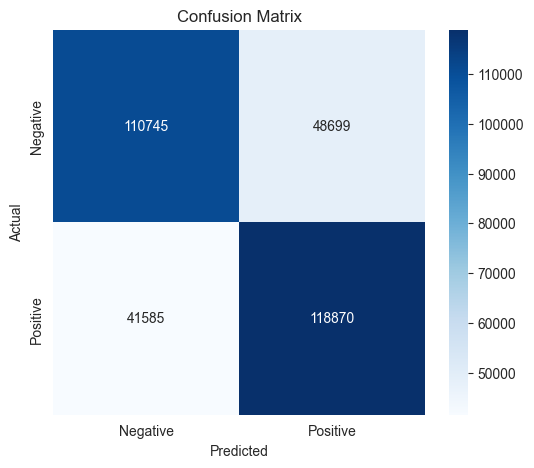

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

